In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import random
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving artist_edges.csv to artist_edges.csv
Saving athletes_edges.csv to athletes_edges.csv
Saving company_edges.csv to company_edges.csv
Saving dataset_descriptions.txt to dataset_descriptions.txt
Saving government_edges.csv to government_edges.csv
Saving new_sites_edges.csv to new_sites_edges.csv
Saving politician_edges.csv to politician_edges.csv
Saving public_figure_edges.csv to public_figure_edges.csv
Saving tvshow_edges.csv to tvshow_edges.csv


In [ ]:
df = pd.read_csv("artist_edges.csv")
print(df.head())
print(df.columns)

   node_1  node_2
0       0    1794
1       0    3102
2       0   16645
3       0   23490
4       0   42128
Index(['node_1', 'node_2'], dtype='object')


In [ ]:
# create network

In [40]:
import networkx as nx

G = nx.from_pandas_edgelist(df, source='node_1', target='node_2')

print("Node Number:", G.number_of_nodes())
print("Edge Number:", G.number_of_edges())

Node Number: 50515
Edge Number: 819306


In [41]:
# basic analysis
print("Is Connected ?", nx.is_connected(G))
print("Component number:", nx.number_connected_components(G))

Is Connected ? True
Component number: 1


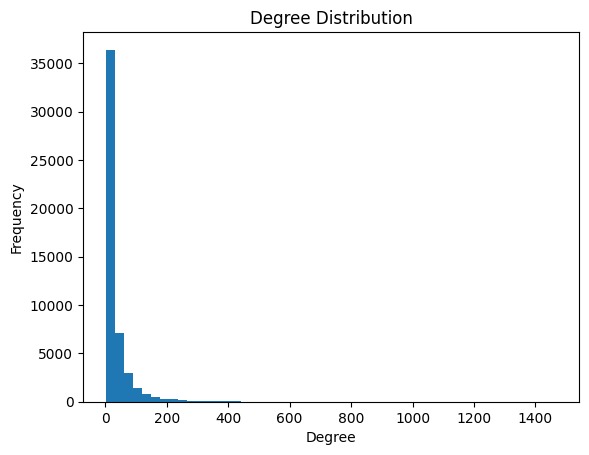

In [42]:
# Degree Distribution
import matplotlib.pyplot as plt

degrees = [d for n, d in G.degree()]

plt.hist(degrees, bins=50)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In [43]:
#Betweeness Centrality
sample_nodes = random.sample(list(G.nodes()), 2000)
G_sample = G.subgraph(sample_nodes)

bet_cent = nx.betweenness_centrality(G_sample)

top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top Betweenness Nodes:")
print(top_bet)

Top Betweenness Nodes:
[(37439, 0.04391258475155093), (22154, 0.02034519360319742), (37329, 0.01401514296646722), (48794, 0.01346026582530842), (137, 0.013283519745522328), (19888, 0.012014102244226969), (34322, 0.010030153366895014), (1367, 0.009791620301052196), (31113, 0.008789653995408094), (45533, 0.008254319715045162)]


In [44]:
#Eigen Vector
eig_cent = nx.eigenvector_centrality(G_sample, max_iter=1000)

top_eig = sorted(eig_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top Eigenvector Nodes:")
print(top_eig)

Top Eigenvector Nodes:
[(37439, 0.4779607285452612), (22154, 0.21014686344496558), (39784, 0.20207140621735387), (26543, 0.1978565134538597), (12270, 0.18816353841440436), (16892, 0.17614175795618833), (12714, 0.1625831943176961), (37329, 0.1507255366639757), (1367, 0.13784141190269472), (33525, 0.13619787412743722)]


In [45]:
#Page Rank
pr = nx.pagerank(G)

top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top PageRank Nodes:")
print(top_pr)

Top PageRank Nodes:
[(48099, 0.0008395299511401832), (41998, 0.0008290134946126336), (7675, 0.0008233448007675681), (9187, 0.0007867797937298446), (46117, 0.0007486419060054941), (37078, 0.0007078547181054742), (13455, 0.0006964354904197494), (37439, 0.0006787822236480252), (6970, 0.0006773126606591094), (31746, 0.0006703475663419558)]


In [46]:
#Centrality
deg_cent = nx.degree_centrality(G)

top_nodes = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print(top_nodes)

[(7675, 0.029081046838500216), (41998, 0.02894247139406897), (48099, 0.026764857267292233), (9187, 0.026289741457813674), (37078, 0.02567605020390387), (13455, 0.02456744664845389), (37439, 0.02434968523577622), (6970, 0.02432988874371461), (31746, 0.0239933483786673), (3875, 0.023914162410420874)]


In [47]:
G_removed = G.copy()

top = [n for n, _ in top_nodes]
G_removed.remove_nodes_from(top)

print("Component number (before):", nx.number_connected_components(G))
print("Component number (after):", nx.number_connected_components(G_removed))

Component number (before): 1
Component number (after): 17


In [ ]:
#

In [48]:
n = G.number_of_nodes()
m = G.number_of_edges()

In [49]:
#erdos renyi GRAPH
p = (2 * m) / (n * (n - 1))  # edge probability

G_er = nx.erdos_renyi_graph(n, p)

print("ER graph Created")

ER graph Created


In [50]:
#Barebasi graph
m_ba = int(m / n)  # average degree approx

G_ba = nx.barabasi_albert_graph(n, m_ba)

print("BA graph created")

BA graph created


In [51]:
# WS graph
k = int(m / n) * 2  # average degree
p_ws = 0.1

G_ws = nx.watts_strogatz_graph(n, k, p_ws)

print("WS graph Created")

WS graph Created


In [52]:
def analyze_graph(graph, name):
    print(f"\n{name}")
    print("Nodes:", graph.number_of_nodes())
    print("Edges:", graph.number_of_edges())
    print("Density:", nx.density(graph))
    print("Avg clustering:", nx.average_clustering(graph))
    print("Connected components:", nx.number_connected_components(graph))

analyze_graph(G, "REAL GRAPH")
analyze_graph(G_er, "ER GRAPH")
analyze_graph(G_ba, "BA GRAPH")
analyze_graph(G_ws, "WS GRAPH")


REAL GRAPH
Nodes: 50515
Edges: 819306
Density: 0.0006421611293685727
Avg clustering: 0.13812042114553713
Connected components: 1

ER GRAPH
Nodes: 50515
Edges: 818865
Density: 0.000641815479442841
Avg clustering: 0.0006486268273016999
Connected components: 1

BA GRAPH
Nodes: 50515
Edges: 807984
Density: 0.0006332870965814199
Avg clustering: 0.0043062852408742355
Connected components: 1

WS GRAPH
Nodes: 50515
Edges: 808240
Density: 0.0006334877459714138
Avg clustering: 0.5312191941259161
Connected components: 1


In [53]:
#Linear Thereshold
thresholds = {node: random.uniform(0.1, 0.5) for node in G.nodes()}


In [54]:
seed_nodes = [n for n, _ in top_nodes]

In [55]:
def linear_threshold(G, seeds, thresholds):
    active = set(seeds)
    new_active = set(seeds)

    while new_active:
        next_active = set()

        for node in G.nodes():
            if node in active:
                continue

            neighbors = list(G.neighbors(node))
            if len(neighbors) == 0:
                continue

            active_neighbors = sum(1 for n in neighbors if n in active)

            if (active_neighbors / len(neighbors)) >= thresholds[node]:
                next_active.add(node)

        new_active = next_active - active
        active.update(new_active)

    return active

In [56]:
active_nodes = linear_threshold(G, seed_nodes, thresholds)

print("Starting node:", len(seed_nodes))
print("Last Active node:", len(active_nodes))

Starting node: 10
Last Active node: 412


In [57]:

random_seeds = random.sample(list(G.nodes()), 10)
active_random = linear_threshold(G, random_seeds, thresholds)

print("Hub seeds spread:", len(active_nodes))
print("Random seeds spread:", len(active_random))

Hub seeds spread: 412
Random seeds spread: 17


In [58]:
#Greedy algorithm
sample_nodes = random.sample(list(G.nodes()), 2000)
G_sample = G.subgraph(sample_nodes)

thresholds_sample = {node: random.uniform(0.1, 0.5) for node in G_sample.nodes()}

In [60]:
def greedy_seed_selection(G, k, thresholds):
    selected_seeds = []

    for i in range(k):
        best_node = None
        best_spread = 0

        candidates = set(G.nodes()) - set(selected_seeds)

        for node in random.sample(list(candidates), min(50, len(candidates))):  # speed hack
            temp_seeds = selected_seeds + [node]
            spread = len(linear_threshold(G, temp_seeds, thresholds))

            if spread > best_spread:
                best_spread = spread
                best_node = node

        selected_seeds.append(best_node)
        print(f"Step {i+1}: Added node {best_node}, spread = {best_spread}")

    return selected_seeds

In [61]:
print("Greedy k=5")
seeds_5 = greedy_seed_selection(G_sample, 5, thresholds_sample)

print("\nGreedy k=10")
seeds_10 = greedy_seed_selection(G_sample, 10, thresholds_sample)

Greedy k=5
Step 1: Added node 48719, spread = 21
Step 2: Added node 34988, spread = 42
Step 3: Added node 29998, spread = 400
Step 4: Added node 358, spread = 429
Step 5: Added node 44983, spread = 436

Greedy k=10
Step 1: Added node 31242, spread = 57
Step 2: Added node 8233, spread = 327
Step 3: Added node 5228, spread = 390
Step 4: Added node 30716, spread = 397
Step 5: Added node 32491, spread = 426
Step 6: Added node 25942, spread = 433
Step 7: Added node 21598, spread = 443
Step 8: Added node 21471, spread = 450
Step 9: Added node 40880, spread = 462
Step 10: Added node 30199, spread = 470


In [62]:
spread_5 = len(linear_threshold(G_sample, seeds_5, thresholds_sample))
spread_10 = len(linear_threshold(G_sample, seeds_10, thresholds_sample))

print("Spread (k=5):", spread_5)
print("Spread (k=10):", spread_10)

Spread (k=5): 436
Spread (k=10): 470
